In [2]:
import os
import shutil
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from sklearn.model_selection import train_test_split
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader



Preprocessing the image + Data Augmentation

In [3]:
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2),
    transforms.ToTensor(),
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

In [ ]:
!====================== online augmentation ======================

def load_dataset(batch_size=32):

    train_data = ImageFolder(
        root="../data_split/train",
        transform=train_transform
    )

    val_data = ImageFolder(
        root="../data_split/val",
        transform=val_test_transform
    )

    test_data = ImageFolder(
        root="../data_split/test",
        transform=val_test_transform
    )

    train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)

    print(f"Training Set: {len(train_data)}")
    print(f"Validation Set: {len(val_data)}")
    print(f"Test Set: {len(test_data)}")

    return train_loader, val_loader, test_loader, train_data

In [26]:
train_loader, val_loader, test_loader, train_data = load_dataset()

Training Set: 902
Validation Set: 193
Test Set: 194


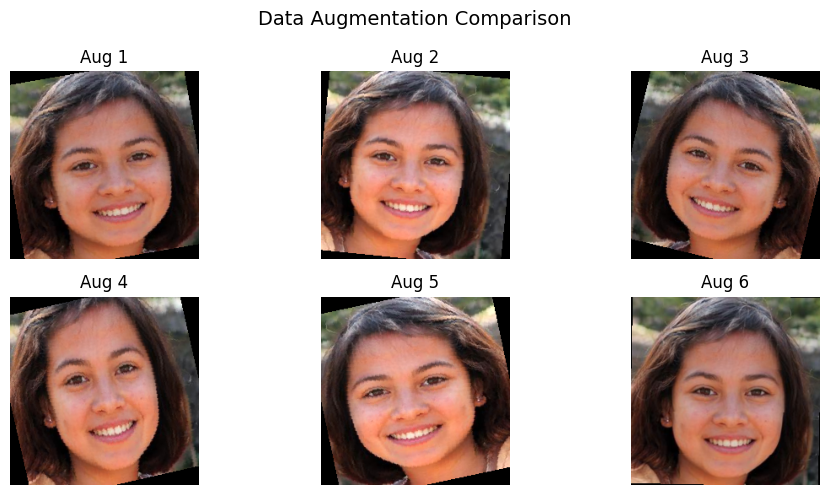

In [ ]:
dataset_raw = ImageFolder(
    root="../data_split/train",
    transform=transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor()
    ])
)

# ======================
# 2. augmentation transform
# ======================
aug_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2),
    transforms.ToTensor(),
])

# ======================
# 3. choose one image
# ======================
img_path, label = dataset_raw.samples[0]

img = Image.open(img_path).convert("RGB")

# ======================
# 4. apply augmentation
# ======================
aug_images = [aug_transform(img) for _ in range(6)]
orig_image = dataset_raw[0][0]

# ======================
# 5. visualize
# ======================
def show(img_tensor):
    img = img_tensor.permute(1, 2, 0).numpy()
    return img

plt.figure(figsize=(10,5))

# original image
plt.subplot(2,3,1)
plt.imshow(show(orig_image))
plt.title("Original")
plt.axis("off")

# augmentation
for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(show(aug_images[i]))
    plt.title(f"Aug {i+1}")
    plt.axis("off")

plt.suptitle("Data Augmentation Comparison", fontsize=14)
plt.tight_layout()
plt.show()

3. Data Validation

3.1 Check the Image and Label

In [ ]:
!====================== check for corrupted images ======================
from PIL import Image
import os

def check_images(folder):
    corrupted = []

    for root, _, files in os.walk(folder):
        for file in files:
            path = os.path.join(root, file)
            try:
                img = Image.open(path)
                img.verify()  # check if image is broken
            except:
                corrupted.append(path)

    return corrupted


corrupted_images = check_images("data_split")

print("Corrupted images found:", len(corrupted_images))
print(corrupted_images[:10])

Corrupted images found: 0
[]


In [ ]:
!====================== check class mapping ======================
from torchvision.datasets import ImageFolder

dataset = ImageFolder("../data_split/train")

print("Class mapping:", dataset.class_to_idx)
print("Classes:", dataset.classes)

Class mapping: {'fake': 0, 'real': 1}
Classes: ['fake', 'real']


In [ ]:
!====================== count images in each split ======================
import os

def count_images(folder):
    real = len(os.listdir(os.path.join(folder, "real")))
    fake = len(os.listdir(os.path.join(folder, "fake")))
    return real, fake


for split in ["train", "val", "test"]:
    real, fake = count_images(f"../data_split/{split}")
    print(f"{split.upper()}: Real={real}, Fake={fake}, Total={real+fake}")

TRAIN: Real=412, Fake=490, Total=902
VAL: Real=88, Fake=105, Total=193
TEST: Real=89, Fake=105, Total=194


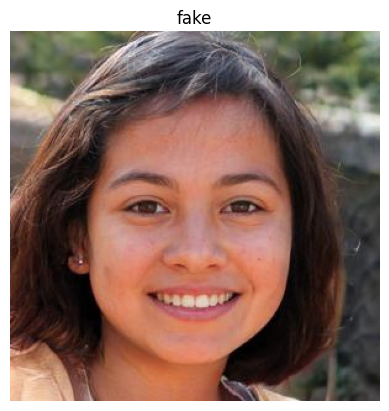

In [ ]:
!====================== visualize sample images ======================
dataset = ImageFolder(
    "../data_split/train",
    transform=transforms.ToTensor()
)

img, label = dataset[0]

plt.imshow(img.permute(1,2,0))
plt.title(dataset.classes[label])
plt.axis("off")
plt.show()

3.2 Check  label and duplicated

In [ ]:
!====================== check for wrong labels ======================
from torchvision.datasets import ImageFolder

dataset = ImageFolder("../data_split/train")

print("Class mapping:", dataset.class_to_idx)

# check samples
for i in range(10):
    path, label = dataset.samples[i]
    print(path, "→", dataset.classes[label])

Class mapping: {'fake': 0, 'real': 1}
../data_split/train/fake/fake_100.jpg → fake
../data_split/train/fake/fake_102.jpg → fake
../data_split/train/fake/fake_103.jpg → fake
../data_split/train/fake/fake_104.jpg → fake
../data_split/train/fake/fake_105.jpg → fake
../data_split/train/fake/fake_108.jpg → fake
../data_split/train/fake/fake_109.jpg → fake
../data_split/train/fake/fake_11.jpg → fake
../data_split/train/fake/fake_111.jpg → fake
../data_split/train/fake/fake_113.jpg → fake


In [ ]:
!====================== check for wrong labels ======================
import os

wrong_labels = []

for root, _, files in os.walk("../data_split/train"):
    for f in files:
        path = os.path.join(root, f)

        if "real" in root and "fake" in f:
            wrong_labels.append(path)

        if "fake" in root and "real" in f:
            wrong_labels.append(path)

print("Wrong label files:", len(wrong_labels))
print(wrong_labels[:10])

Wrong label files: 0
[]


In [ ]:
!====================== check for duplicate filenames ======================
import os
from collections import defaultdict

files_dict = defaultdict(list)

for root, _, files in os.walk("../data_split/train"):
    for f in files:
        files_dict[f].append(os.path.join(root, f))

duplicates = {k:v for k,v in files_dict.items() if len(v) > 1}

print("Duplicate filenames:", len(duplicates))

Duplicate filenames: 0


In [ ]:
!====================== check for duplicate images using hash ======================
import hashlib

def get_hash(path):
    with open(path, "rb") as f:
        return hashlib.md5(f.read()).hexdigest()

hash_map = {}
duplicates = []

for root, _, files in os.walk("data_split/train"):
    for f in files:
        path = os.path.join(root, f)
        file_hash = get_hash(path)

        if file_hash in hash_map:
            duplicates.append((path, hash_map[file_hash]))
        else:
            hash_map[file_hash] = path

print("Duplicate images found:", len(duplicates))
print(duplicates[:5])

Duplicate images found: 0
[]
